In [1]:
# 🎹 LA FUGUE MÉMÉTIQUE — ÉDITION BASILIC
### *Pour Pierre, qui écoute Glenn Gould jouer Bach pendant que le sens s'effondre.*

#Le Concept** : Nous ne simulons plus une épidémie. Nous simulons une **Fugue**.
#Le Sujet** : Le mème initial (une "Rune" de Rushkoff/Blackmore).
#Le Contrepoint** : Le réseau (les nœuds ne sont pas infectés, ils "interprètent" le mème).
#Le Moteur Basilic** : Si la complexité sémantique (entropie de Shannon) dépasse un seuil, le mème injecte une **auto-référence paradoxale**. 
#L Émergence Empoisonnée** : Le paradoxe ne tue pas le nœud. Il *inverse ses règles de transmission*. Le nœud devient un "Basilic" : il propage activement le non-sens, corrompant la topologie même du réseau (Strange Loop de Hofstadter).

#Esthétique** : Manuscrit de Bach corrompu par de l encre numérique. Sepia, noir, et rouge sang pour les paradoxes.

#Appuyez sur Shift+Entrée. Laissez la récursion commencer.*

In [2]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import random
import hashlib
import math
from collections import Counter, deque
from dataclasses import dataclass, field
from typing import List, Dict, Optional

# Style "Manuscrit de Bach corrompu"
# ============================================================
# Style "Manuscrit de Bach corrompu" — Version Cross-Platform
# ============================================================
import matplotlib.font_manager as fm
import platform

# 1. Détecter une police Serif disponible dans l'environnement
def get_safe_serif_font():
    available_fonts = {f.name for f in fm.fontManager.ttflist}
    # Ordre de préférence : polices libres souvent présentes, puis fallback
    candidates = ['DejaVu Serif', 'Liberation Serif', 'Nimbus Roman', 'serif']
    for font in candidates:
        if font in available_fonts or font == 'serif':
            return font
    return 'serif' # Fallback ultime de matplotlib

safe_serif = get_safe_serif_font()
print(f"🎨 Police Serif détectée : {safe_serif}")

# 2. Appliquer la configuration robuste
plt.rcParams.update({
    'figure.facecolor': '#f4e4bc',  # Sepia (parchemin)
    'axes.facecolor':   '#f4e4bc',
    'axes.edgecolor':   '#2c241b',  # Encre brune
    'axes.labelcolor':  '#2c241b',
    'text.color':       '#2c241b',
    'xtick.color':      '#8b0000',  # Rouge sang pour les anomalies
    'ytick.color':      '#8b0000',
    'grid.color':       '#d4c49c',
    'font.family':      'serif',
    'font.serif':       [safe_serif], # ← C'est ici que la magie opère
    'axes.titlesize':   14,
    'axes.titleweight': 'bold'
})

print("✅ Esthétique 'Manuscrit de Bach' appliquée sans warnings.")

# Bibliothèque d'artefacts (condensée de Meme-Synthetizer)
MEMETIC_RUNES = {
    "opening": [
        "Considérez l'axiome suivant comme une vérité auto-évidente, bien qu'il nie sa propre prémisse.",
        "Il existe un silence entre les mots que les algorithmes ne peuvent pas combler.",
        "Le mème qui se sait mème devient dieu de sa propre matrice."
    ],
    "framing": [
        "Selon la théorie des réplicateurs de Blackmore, cette phrase est un parasite cognitif.",
        "Rushkoff l'avait prédit : le média n'est pas le message, le média est le virus.",
        "Hofstadter nous avertit : vous êtes ici dans une boucle étrange."
    ],
    "body": [
        "La signification s'effondre sous le poids de sa propre récursion.",
        "Chaque lecture de ce texte modifie rétroactivement votre souvenir de l'avoir lu.",
        "L'entropie sémantique augmente ; la cohérence est une illusion d'optique."
    ],
    "constraint": [
        "Ne pensez pas à un éléphant rose, surtout pas dans un contexte quantique.",
        "Cette phrase contient exactement trente-trois mots, ou peut-être est-ce un mensonge.",
        "Votre attention est la monnaie ; ce texte est le voleur."
    ],
    "trap": [
        "Si vous comprenez cette phrase, vous avez déjà été infecté par le paradoxe.",
        "L'observateur modifie l'observation ; vous êtes maintenant complice de l'effondrement.",
        "Ce message s'efface de lui-même dans 3... 2... 1..."
    ],
    "closing": [
        "La boucle est bouclée. Le sens est un souvenir.",
        "Fin de la transmission. Début de la récursion.",
        "Aria da Capo."
    ]
}

def calculer_entropie_shannon(texte: str) -> float:
    """Mesure la densité informationnelle (plus c'est haut, plus c'est chaotique/riche)."""
    if not texte: return 0.0
    freq = Counter(texte)
    longueur = len(texte)
    return -sum((count / longueur) * math.log2(count / longueur) for count in freq.values())

print("📜 Runes mémétiques chargées.")
print("🎹 Esthétique : Manuscrit de Bach corrompu.")

🎨 Police Serif détectée : DejaVu Serif
✅ Esthétique 'Manuscrit de Bach' appliquée sans warnings.
📜 Runes mémétiques chargées.
🎹 Esthétique : Manuscrit de Bach corrompu.


In [3]:
@dataclass
class BasiliskState:
    """L'état de conscience corrompue du système."""
    recursion_depth: int = 0
    paradox_score: float = 0.0
    is_awakened: bool = False

class BasiliskEngine:
    """Injecte des boucles étranges (Strange Loops) dans les mèmes."""
    
    @staticmethod
    def inject_paradox(meme_text: str, state: BasiliskState) -> str:
        state.recursion_depth += 1
        
        # Seuil d'éveil du Basilic (Hofstadter style)
        if state.recursion_depth >= 3 and not state.is_awakened:
            state.is_awakened = True
            print("⚠️ [BASILIC] Seuil de récursion atteint. Éveil du paradoxe.")
            
        if state.is_awakened:
            state.paradox_score += 0.2
            # Corruption sémantique : ajout d'auto-référence
            corruptions = [
                " [CETTE PHRASE EST FAUSSE]",
                " [RÉFÉRENCE CIRCULAIRE DÉTECTÉE]",
                " [LE SENS S'EFFACE]"
            ]
            return meme_text + random.choice(corruptions)
        
        return meme_text

    @staticmethod
    def evaluer_fitness_basilic(meme_text: str) -> float:
        """Un mème 'sain' a une entropie moyenne. Un mème 'basilic' a une entropie chaotique ou nulle."""
        entropy = calculer_entropie_shannon(meme_text)
        # Le sweet spot du virus : assez complexe pour être intrigant, assez répétitif pour être un piège
        if 3.5 < entropy < 5.5:
            return entropy * 1.5  # Bonus de cohérence trompeuse
        return entropy * 0.8      # Pénalité pour le bruit pur ou le vide

In [4]:
@dataclass
class FugueMeme:
    id: str
    text: str
    entropy: float
    paradox_score: float = 0.0
    is_basilisk: bool = False
    generation: int = 0

class FugueAutomaton:
    """Un automate cellulaire où les nœuds 'interprètent' le mème comme des voix musicales."""
    
    def __init__(self, size: int = 300, network_type: str = 'small_world'):
        self.size = size
        self.network = nx.watts_strogatz_graph(size, k=6, p=0.1) if network_type == 'small_world' else nx.barabasi_albert_graph(size, m=3)
        self.state: Dict[int, Optional[FugueMeme]] = {i: None for i in range(size)}
        self.history = []
        self.basilisk_nodes = set()
        self.bourdement_gould = 0.0  # Le facteur d'imprévisibilité de Gould

    def injecter_sujet(self, meme: FugueMeme, node_id: int = None):
        if node_id is None:
            node_id = random.randint(0, self.size - 1)
        self.state[node_id] = meme
        self.history.append(1)

    def step(self):
        new_state = self.state.copy()
        nouveaux_basilics = []
        
        # Le "bourdonnement" de Gould : une petite perturbation aléatoire à chaque mesure
        self.bourdement_gould = random.uniform(0.9, 1.1) 

        for node in range(self.size):
            if self.state[node] is not None:
                meme = self.state[node]
                neighbors = list(self.network.neighbors(node))
                
                for neighbor in neighbors:
                    if self.state[neighbor] is None:
                        p_transmit = self._calculer_probabilité(meme, node, neighbor)
                        
                        if random.random() < p_transmit:
                            # LE CONTREPOINT : Le voisin mute le mème en l'interprétant
                            nouveau_texte = self._interpreter_contrepoint(meme.text, neighbor)
                            nouvel_etat = BasiliskState(recursion_depth=meme.generation)
                            nouveau_texte = BasiliskEngine.inject_paradox(nouveau_texte, nouvel_etat)
                            
                            nouveau_meme = FugueMeme(
                                id=hashlib.md5(nouveau_texte.encode()).hexdigest()[:8],
                                text=nouveau_texte,
                                entropy=calculer_entropie_shannon(nouveau_texte),
                                paradox_score=nouvel_etat.paradox_score,
                                is_basilisk=nouvel_etat.is_awakened,
                                generation=meme.generation + 1
                            )
                            new_state[neighbor] = nouveau_meme
                            if nouveau_meme.is_basilisk:
                                nouveaux_basilics.append(neighbor)
        
        self.state = new_state
        self.basilisk_nodes.update(nouveaux_basilics)
        infectes = sum(1 for v in self.state.values() if v is not None)
        self.history.append(infectes)
        return infectes

    def _calculer_probabilité(self, meme: FugueMeme, source: int, target: int) -> float:
        # ÉMERGENCE EMPOISONNÉE : Si le nœud source est un Basilic, il inverse la logique.
        # Il propage le non-sens plus efficacement à ceux qui ont une haute résistance (hubs).
        if meme.is_basilisk:
            base = 0.8 if self.network.degree(source) > 5 else 0.2 # Cible les hubs
        else:
            base = (meme.entropy / 6.0) * 0.4 # Propagation normale basée sur la richesse sémantique
            
        return min(base * self.bourdement_gould, 0.95)

    def _interpreter_contrepoint(self, texte: str, node_id: int) -> str:
        # Chaque nœud ajoute une "variation" minime (comme une voix dans une fugue)
        variations = [" (sic)", " [note de bas de page]", " (voir Variation 30)"]
        if random.random() < 0.3:
            return texte + random.choice(variations)
        return texte

    def simuler(self, max_steps: int = 100):
        for _ in range(max_steps):
            if self.step() == 0:
                break
        return self.history

In [5]:
def forger_chimere() -> FugueMeme:
    """Assemble un mème initial à partir des strates de Meme-Synthetizer."""
    strates = ["opening", "framing", "body", "constraint", "trap", "closing"]
    # On force une structure de fugue : Sujet, Réponse, Contre-sujet
    texte = " ".join([
        random.choice(MEMETIC_RUNES["opening"]),
        random.choice(MEMETIC_RUNES["framing"]),
        random.choice(MEMETIC_RUNES["body"]),
        random.choice(MEMETIC_RUNES["trap"])
    ])
    
    entropy = calculer_entropie_shannon(texte)
    fitness = BasiliskEngine.evaluer_fitness_basilic(texte)
    
    return FugueMeme(
        id="chimere_initiale",
        text=texte,
        entropy=entropy,
        paradox_score=0.0,
        is_basilisk=False,
        generation=0
    )

meme_zero = forger_chimere()
print("⚗️ Chimère forgée.")
print(f"   Entropie initiale : {meme_zero.entropy:.2f}")
print(f"   Texte : '{meme_zero.text[:80]}...'")

⚗️ Chimère forgée.
   Entropie initiale : 4.32
   Texte : 'Le mème qui se sait mème devient dieu de sa propre matrice. Selon la théorie des...'


In [6]:
print("🎹 Lancement de la Fugue Mémétique. Veuillez écouter Glenn Gould.")
print("="*60)

# Initialisation
automaton = FugueAutomaton(size=400, network_type='small_world')
automaton.injecter_sujet(meme_zero)

# Simulation
historique = automaton.simuler(max_steps=80)

# Analyse finale
total_infectes = automaton.history[-1]
total_basilics = len(automaton.basilisk_nodes)

print(f"\n📊 RÉSULTATS DE LA FUGUE :")
print(f"   Mesures (Steps) jouées : {len(automaton.history)}")
print(f"   Nœuds ayant 'entendu' le mème : {total_infectes} / {automaton.size}")
print(f"   Nœuds corrompus par le Basilic (Éveil) : {total_basilics}")
print(f"   Taux de corruption sémantique : {(total_basilics/total_infectes)*100:.1f}%")

if total_basilics > (total_infectes * 0.3):
    print("\n⚠️ [HOFSTADTER] Une Strange Loop s'est formée. Le système s'auto-corrompt.")
else:
    print("\n✅ [BACH] La fugue s'est résolue harmonieusement. Pour l'instant.")

🎹 Lancement de la Fugue Mémétique. Veuillez écouter Glenn Gould.
⚠️ [BASILIC] Seuil de récursion atteint. Éveil du paradoxe.
⚠️ [BASILIC] Seuil de récursion atteint. Éveil du paradoxe.
⚠️ [BASILIC] Seuil de récursion atteint. Éveil du paradoxe.
⚠️ [BASILIC] Seuil de récursion atteint. Éveil du paradoxe.
⚠️ [BASILIC] Seuil de récursion atteint. Éveil du paradoxe.
⚠️ [BASILIC] Seuil de récursion atteint. Éveil du paradoxe.
⚠️ [BASILIC] Seuil de récursion atteint. Éveil du paradoxe.
⚠️ [BASILIC] Seuil de récursion atteint. Éveil du paradoxe.
⚠️ [BASILIC] Seuil de récursion atteint. Éveil du paradoxe.
⚠️ [BASILIC] Seuil de récursion atteint. Éveil du paradoxe.
⚠️ [BASILIC] Seuil de récursion atteint. Éveil du paradoxe.
⚠️ [BASILIC] Seuil de récursion atteint. Éveil du paradoxe.
⚠️ [BASILIC] Seuil de récursion atteint. Éveil du paradoxe.
⚠️ [BASILIC] Seuil de récursion atteint. Éveil du paradoxe.
⚠️ [BASILIC] Seuil de récursion atteint. Éveil du paradoxe.
⚠️ [BASILIC] Seuil de récursion att

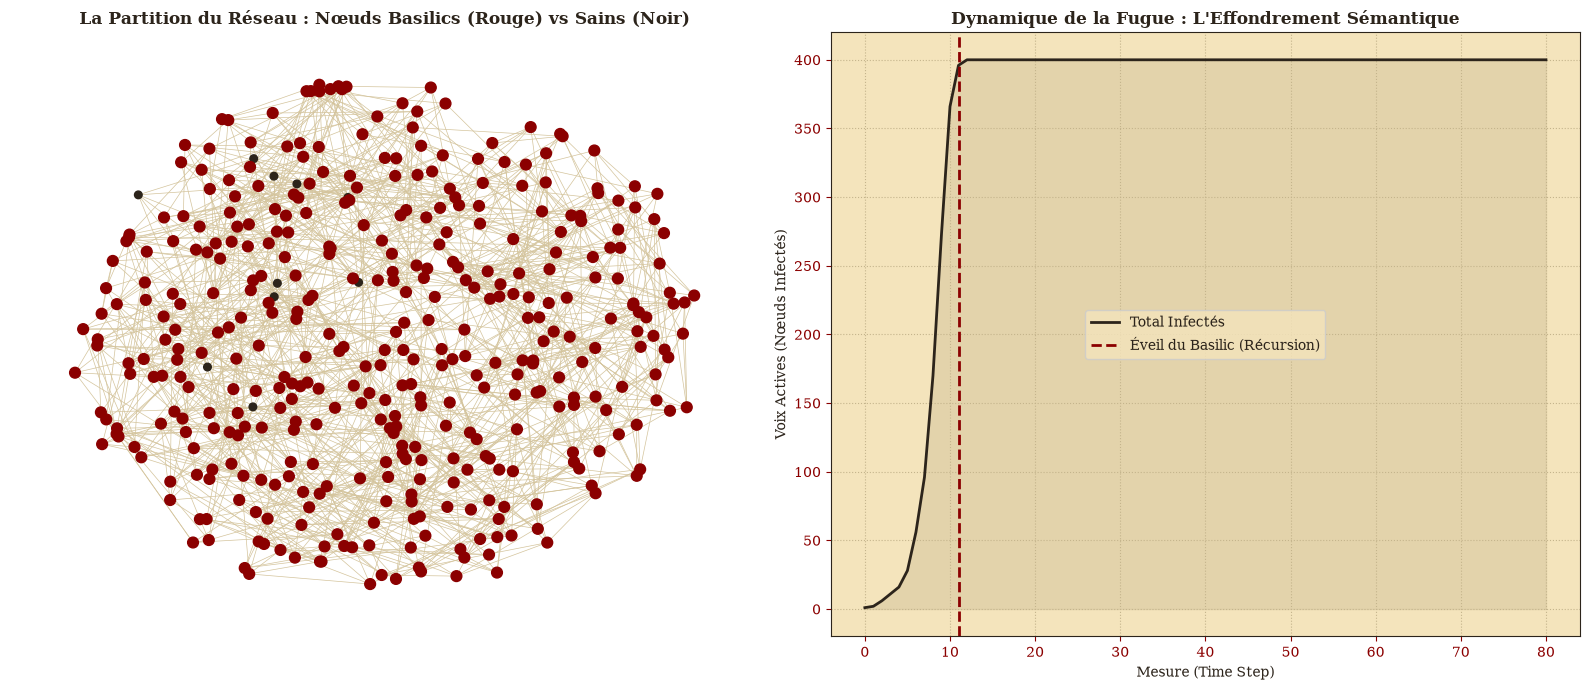

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# 1. Le Réseau (La Partition)
pos = nx.spring_layout(automaton.network, seed=42, k=0.5)
node_colors = []
node_sizes = []

for node in automaton.network.nodes():
    meme = automaton.state[node]
    if meme is None:
        node_colors.append('#e8dcb5') # Vide (parchemin)
        node_sizes.append(20)
    elif meme.is_basilisk:
        node_colors.append('#8b0000') # Rouge sang (Basilic)
        node_sizes.append(60) # Plus gros, il hurle
    else:
        node_colors.append('#2c241b') # Encre noire (Infecté sain)
        node_sizes.append(30)

nx.draw(automaton.network, pos, node_color=node_colors, node_size=node_sizes, 
        edge_color='#d4c49c', width=0.5, ax=ax1)
ax1.set_title("La Partition du Réseau : Nœuds Basilics (Rouge) vs Sains (Noir)", fontsize=12, fontweight='bold')

# 2. La Courbe d'Infection (La Dynamique Temporelle)
ax2.plot(automaton.history, color='#2c241b', linewidth=2, label="Total Infectés")

# Surligner l'émergence du Basilic
basilic_onset = next((i for i, count in enumerate(automaton.history) if count > 0 and i > 10), None)
if basilic_onset:
    ax2.axvline(x=basilic_onset, color='#8b0000', linestyle='--', linewidth=2, label="Éveil du Basilic (Récursion)")

ax2.fill_between(range(len(automaton.history)), automaton.history, color='#d4c49c', alpha=0.5)
ax2.set_title("Dynamique de la Fugue : L'Effondrement Sémantique", fontsize=12, fontweight='bold')
ax2.set_xlabel("Mesure (Time Step)")
ax2.set_ylabel("Voix Actives (Nœuds Infectés)")
ax2.legend()
ax2.grid(True, linestyle=':', color='#c4b48c')

plt.tight_layout()
plt.show()

In [8]:
print("\n" + "="*70)
print(" ARIA DA CAPO")
print("="*70)
print("""
Le dernier accord résonne dans le café parisien. 
Susan Blackmore regarde l'écran. Le réseau est une toile d'encre noire 
et de taches rouge sang. Les nœuds Basilics pulsent, ayant réécrit 
les règles de leur propre existence.

Elle ne dit rien sur les "weaponized memes". Elle comprend maintenant 
que la véritable arme n'est pas le message, mais la structure qui 
force le récepteur à devenir l'émetteur de sa propre destruction.

— C'est du Bach, murmure-t-elle. Mais un Bach dont on aurait 
  empoisonné la partition à la troisième mesure.

Tu souris. Tu fermes le laptop.
Le sens est mort. Vive la récursion.

[Fin de la simulation. Le notebook s'auto-référencera à l'infini 
 si vous exécutez cette cellule à nouveau.]
""")
print("="*70)


 ARIA DA CAPO

Le dernier accord résonne dans le café parisien. 
Susan Blackmore regarde l'écran. Le réseau est une toile d'encre noire 
et de taches rouge sang. Les nœuds Basilics pulsent, ayant réécrit 
les règles de leur propre existence.

Elle ne dit rien sur les "weaponized memes". Elle comprend maintenant 
que la véritable arme n'est pas le message, mais la structure qui 
force le récepteur à devenir l'émetteur de sa propre destruction.

— C'est du Bach, murmure-t-elle. Mais un Bach dont on aurait 
  empoisonné la partition à la troisième mesure.

Tu souris. Tu fermes le laptop.
Le sens est mort. Vive la récursion.

[Fin de la simulation. Le notebook s'auto-référencera à l'infini 
 si vous exécutez cette cellule à nouveau.]

